# Network Group Validation

This notebook compares real Raspberry Pi network/control HPC data against the synthetic network group:

- TP-Link Omada
- Smart Thermostat
- Medical Monitor
- Smart Agriculture


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files

## We upload files

In [ ]:
uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))
print("\nFiles in session:")
for f in sorted(os.listdir()):
    print("-", f)

Saving real_network_perf_30ms.csv to real_network_perf_30ms.csv
Saving tplink_omada_hpc_20251014_220243.csv to tplink_omada_hpc_20251014_220243.csv
Uploaded files: ['real_network_perf_30ms.csv', 'tplink_omada_hpc_20251014_220243.csv']

Files in session:
- .config
- real_network_cleaned_hpc.csv
- real_network_perf_30ms.csv
- sample_data
- tplink_omada_hpc_20251014_220243.csv


##  Parser, cleaning, and helper functions

In [ ]:
def parse_perf_stat_interval_csv(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(";")]
            if len(parts) < 4:
                continue
            try:
                t = float(parts[0])
            except ValueError:
                continue
            raw_value = parts[1]
            event = parts[3].split(":")[0]
            if "<not supported>" in raw_value:
                continue
            try:
                value = float(raw_value.replace(",", ""))
            except ValueError:
                continue
            rows.append({"time_sec": t, "event": event, "value": value})

    df = pd.DataFrame(rows)
    wide_df = df.pivot_table(
        index="time_sec",
        columns="event",
        values="value",
        aggfunc="first"
    ).reset_index()
    wide_df.columns.name = None
    return wide_df

def convert_real_perf_to_project_schema(df):
    out = pd.DataFrame()
    out["timestamp"] = df["time_sec"]
    out["hw_cpu_cycles"] = df.get("cycles", 0.0)
    out["hw_instructions_retired"] = df.get("instructions", 0.0)
    out["hw_cache_references"] = df.get("cache-references", 0.0)
    cache_misses = df.get("cache-misses", 0.0)

    out["hw_instructions_per_cycle"] = (
        out["hw_instructions_retired"] / out["hw_cpu_cycles"].replace(0, np.nan)
    ).fillna(0)

    out["hw_cache_miss_rate"] = (
        cache_misses / out["hw_cache_references"].replace(0, np.nan)
    ).fillna(0)
    return out

shared_cols = [
    "hw_cpu_cycles",
    "hw_instructions_retired",
    "hw_instructions_per_cycle",
    "hw_cache_references",
    "hw_cache_miss_rate",
]

ratio_cols = [
    "hw_instructions_per_cycle",
    "hw_cache_miss_rate",
]

def log_mean_cosine(real_df, synth_df, cols):
    real_mean = np.log1p(real_df[cols]).mean().values.reshape(1, -1)
    synth_mean = np.log1p(synth_df[cols]).mean().values.reshape(1, -1)
    return cosine_similarity(real_mean, synth_mean)[0, 0], real_mean, synth_mean

def ratio_cosine(real_df, synth_df, cols):
    real_mean = real_df[cols].mean().values.reshape(1, -1)
    synth_mean = synth_df[cols].mean().values.reshape(1, -1)
    return cosine_similarity(real_mean, synth_mean)[0, 0]

def percent_diff_table(real_df, synth_df, cols, synth_name="synthetic"):
    out = pd.DataFrame({
        "real_mean": real_df[cols].mean(),
        f"{synth_name}_mean": synth_df[cols].mean()
    })
    out["abs_diff"] = (out["real_mean"] - out[f"{synth_name}_mean"]).abs()
    out["percent_diff_vs_real"] = (
        out["abs_diff"] / out["real_mean"].replace(0, np.nan)
    ) * 100
    return out

def make_boxplots(real_df, synth_df, label, cols):
    for col in cols:
        plt.figure(figsize=(7,4))
        plt.boxplot(
            [real_df[col].dropna(), synth_df[col].dropna()],
            labels=[f"Real {col}", f"{label} {col}"]
        )
        plt.title(f"Comparison of {col}: Real vs {label}")
        plt.tight_layout()
        plt.show()

def compare_device(real_clean, synth_df, device_label):
    synth_active = synth_df[synth_df["workload_intensity"] > 10].copy()
    synth_subset = synth_active[shared_cols].copy()
    real_subset = real_clean[shared_cols].copy()

    log_cos, real_mean, synth_mean = log_mean_cosine(real_subset, synth_subset, shared_cols)
    ratio_cos = ratio_cosine(real_clean, synth_active, ratio_cols)

    print(f"=== {device_label} ===")
    print("Cosine similarity (log-mean profile):", round(log_cos, 3))
    print("Cosine similarity (ratios only):", round(ratio_cos, 3))

    profile_df = pd.DataFrame({
        "feature": shared_cols,
        "real_log_mean": real_mean.flatten(),
        f"{device_label}_log_mean": synth_mean.flatten()
    })
    display(profile_df)

    full_compare = percent_diff_table(real_subset, synth_subset, shared_cols, synth_name=device_label.lower().replace(" ", "_"))
    ratio_compare = percent_diff_table(real_clean, synth_active, ratio_cols, synth_name=device_label.lower().replace(" ", "_"))

    print(f"{device_label} full-feature comparison")
    display(full_compare.round(6))

    print(f"{device_label} ratio comparison")
    display(ratio_compare.round(6))

    make_boxplots(real_clean, synth_active, device_label, ratio_cols)

    return {
        "comparison": device_label,
        "log_mean_cosine": log_cos,
        "ratio_cosine": ratio_cos,
        "rows_real": len(real_clean),
        "rows_synth_active": len(synth_active),
    }

## Detect filenames automatically

In [ ]:
def first_match(substrings):
    files_in_session = os.listdir()
    for sub in substrings:
        matches = [f for f in files_in_session if sub in f and f.endswith(".csv")]
        if matches:
            return matches[0]
    return None

REAL_NETWORK_FILE = first_match(["real_network_perf_30ms"])
REAL_CONTROL_FILE = first_match(["real_control_perf_30ms"])

device_files = {
    "TP-Link Omada": first_match(["tplink_omada", "tp_link", "omada"]),
    "Smart Thermostat": first_match(["smart_thermostat"]),
    "Medical Monitor": first_match(["medical_monitor"]),
    "Smart Agriculture": first_match(["smart_agriculture"]),
}

print("REAL_NETWORK_FILE:", REAL_NETWORK_FILE)
print("REAL_CONTROL_FILE:", REAL_CONTROL_FILE)

print("\nDetected synthetic device files:")
for k, v in device_files.items():
    print("-", k, "=>", v)

assert (REAL_NETWORK_FILE is not None) or (REAL_CONTROL_FILE is not None),     "Upload at least one real file: real_network_perf_30ms.csv or real_control_perf_30ms.csv"

available_devices = {k: v for k, v in device_files.items() if v is not None}
assert available_devices, "No network/control synthetic device CSVs found."

REAL_NETWORK_FILE: real_network_perf_30ms.csv
REAL_CONTROL_FILE: None

Detected synthetic device files:
- TP-Link Omada => tplink_omada_hpc_20251014_220243.csv
- Smart Thermostat => None
- Medical Monitor => None
- Smart Agriculture => None


## Load and clean any real reference files

In [ ]:
real_refs = {}

if REAL_NETWORK_FILE is not None:
    real_network_raw = parse_perf_stat_interval_csv(REAL_NETWORK_FILE)
    real_network_clean = convert_real_perf_to_project_schema(real_network_raw)
    real_network_clean.to_csv("real_network_cleaned_hpc.csv", index=False)
    real_refs["network"] = real_network_clean
    print("Loaded real network dataset:")
    display(real_network_clean.head())

if REAL_CONTROL_FILE is not None:
    real_control_raw = parse_perf_stat_interval_csv(REAL_CONTROL_FILE)
    real_control_clean = convert_real_perf_to_project_schema(real_control_raw)
    real_control_clean.to_csv("real_control_cleaned_hpc.csv", index=False)
    real_refs["control"] = real_control_clean
    print("Loaded real control dataset:")
    display(real_control_clean.head())

Loaded real network dataset:


,timestamp,hw_cpu_cycles,hw_instructions_retired,hw_cache_references,hw_instructions_per_cycle,hw_cache_miss_rate
0,0.030300,94226723.0,28801453.0,11830094.0,0.305661,0.026712
1,0.064007,135378445.0,18584312.0,12657491.0,0.137277,0.031024
2,0.094740,108132951.0,15452963.0,11005088.0,0.142907,0.031918
3,0.125368,112589030.0,15004149.0,10711456.0,0.133265,0.030819
4,0.155960,113104498.0,14729440.0,10276034.0,0.130229,0.031245


## Load available synthetic device files

In [ ]:
loaded_devices = {}
for device_label, file_name in available_devices.items():
    synth_df = pd.read_csv(file_name)
    loaded_devices[device_label] = synth_df
    print(f"Loaded {device_label} from {file_name}")
    display(synth_df.head())

Loaded TP-Link Omada from tplink_omada_hpc_20251014_220243.csv


,timestamp,workload_state,workload_intensity,workload_raw,hw_cpu_cycles,hw_instructions_retired,hw_instructions_per_cycle,hw_branch_instructions,hw_branch_miss_rate,hw_cache_references,...,cpu_freq,cpu_utilization,memory_usage_mb,connected_devices,managed_aps,network_throughput_mbps,connected_clients,security_events,packet_loss_rate,wifi_interference
0,2025-10-14 21:52:42.003248,0,76.986645,3079.465806,2748007,2234114,0.812994,176273,0.032206,281194,...,1800.0,81.589316,465.479968,45,8,842,64,4,0.097973,2
1,2025-10-14 21:52:42.033316,0,76.911645,3076.465806,3011825,2440890,0.810436,220487,0.027072,225188,...,1800.0,81.529316,465.367468,45,8,903,69,4,0.036658,5
2,2025-10-14 21:52:42.063383,0,76.936645,3077.465806,2656040,2833923,1.066973,196748,0.029169,244835,...,1800.0,81.549316,465.404968,45,8,953,70,4,0.078637,5
3,2025-10-14 21:52:42.093448,0,76.936645,3077.465806,3111243,2102596,0.675806,160625,0.041407,328610,...,1800.0,81.549316,465.404968,45,8,919,69,3,0.079711,2
4,2025-10-14 21:52:42.123513,0,76.986645,3079.465806,3313170,2932755,0.885181,162132,0.047332,254943,...,1800.0,81.589316,465.479968,45,8,974,74,3,0.031359,5


## Network validation

Running network validation...
=== Network vs TP-Link Omada ===
Cosine similarity (log-mean profile): 0.998
Cosine similarity (ratios only): 0.992


,feature,real_log_mean,Network vs TP-Link Omada_log_mean
0,hw_cpu_cycles,18.580377,14.944290
1,hw_instructions_retired,16.661881,14.801126
2,hw_instructions_per_cycle,0.137202,0.626680
3,hw_cache_references,16.278639,12.580435
4,hw_cache_miss_rate,0.028938,0.058924


Network vs TP-Link Omada full-feature comparison


,real_mean,network_vs_tp-link_omada_mean,abs_diff,percent_diff_vs_real
hw_cpu_cycles,1.177510e+08,3.137846e+06,1.146131e+08,97.335185
hw_instructions_retired,1.730189e+07,2.719727e+06,1.458217e+07,84.280754
hw_instructions_per_cycle,1.470980e-01,8.755820e-01,7.284850e-01,495.239025
hw_cache_references,1.178973e+07,2.956441e+05,1.149408e+07,97.492358
hw_cache_miss_rate,2.936200e-02,6.076000e-02,3.139800e-02,106.935154


Network vs TP-Link Omada ratio comparison


,real_mean,network_vs_tp-link_omada_mean,abs_diff,percent_diff_vs_real
hw_instructions_per_cycle,0.147098,0.875582,0.728485,495.239025
hw_cache_miss_rate,0.029362,0.060760,0.031398,106.935154


/tmp/ipykernel_2750/1503316048.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


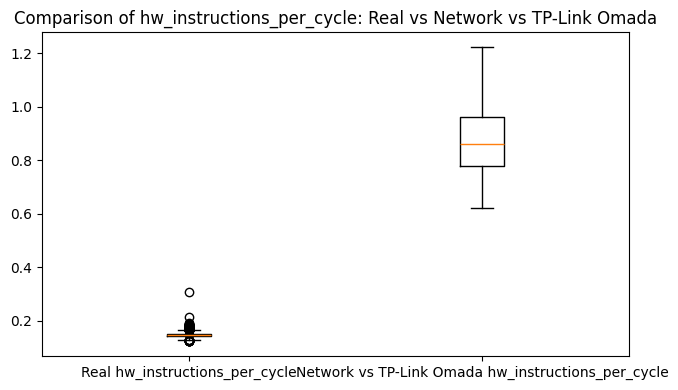

/tmp/ipykernel_2750/1503316048.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


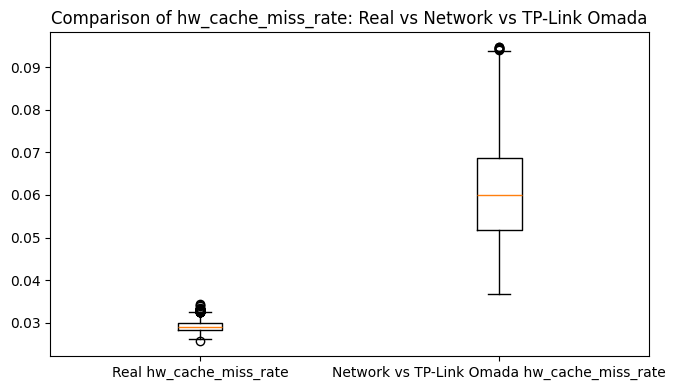

Optional broader network/control comparisons using the network trace:
Network validation summary


,comparison,log_mean_cosine,ratio_cosine,rows_real,rows_synth_active
0,Network vs TP-Link Omada,0.998139,0.991853,1863,20000


In [ ]:
network_results = []

if "network" in real_refs:
    print("Running network validation...")

    preferred_network_devices = ["TP-Link Omada"]
    for device_label in preferred_network_devices:
        if device_label in loaded_devices:
            network_results.append(compare_device(real_refs["network"], loaded_devices[device_label], f"Network vs {device_label}"))

    print("Optional broader network/control comparisons using the network trace:")
    for device_label, synth_df in loaded_devices.items():
        if device_label not in preferred_network_devices:
            network_results.append(compare_device(real_refs["network"], synth_df, f"Network vs {device_label}"))

    network_summary = pd.DataFrame(network_results)
    print("Network validation summary")
    display(network_summary.round(6))
else:
    print("No real network file uploaded, skipping network validation.")

## Control validation

In [ ]:
control_results = []

if "control" in real_refs:
    print("Running control validation...")

    preferred_control_devices = ["Smart Thermostat", "Medical Monitor", "Smart Agriculture"]
    for device_label in preferred_control_devices:
        if device_label in loaded_devices:
            control_results.append(compare_device(real_refs["control"], loaded_devices[device_label], f"Control vs {device_label}"))

    print("Optional broader network/control comparisons using the control trace:")
    for device_label, synth_df in loaded_devices.items():
        if device_label not in preferred_control_devices:
            control_results.append(compare_device(real_refs["control"], synth_df, f"Control vs {device_label}"))

    control_summary = pd.DataFrame(control_results)
    print("Control validation summary")
    display(control_summary.round(6))
else:
    print("No real control file uploaded, skipping control validation.")

No real control file uploaded, skipping control validation.


## Pairwise ratio-only cosine across the synthetic network group

In [ ]:
device_names = list(loaded_devices.keys())
mat = pd.DataFrame(index=device_names, columns=device_names, dtype=float)

for d1 in device_names:
    for d2 in device_names:
        a = loaded_devices[d1][loaded_devices[d1]["workload_intensity"] > 10][ratio_cols].mean().values.reshape(1, -1)
        b = loaded_devices[d2][loaded_devices[d2]["workload_intensity"] > 10][ratio_cols].mean().values.reshape(1, -1)
        mat.loc[d1, d2] = cosine_similarity(a, b)[0, 0]

print("Pairwise ratio-only cosine similarity across network/control synthetic devices:")
display(mat.round(6))

Pairwise ratio-only cosine similarity across network/control synthetic devices:


,TP-Link Omada
TP-Link Omada,1.0
